## Step 1 — Imports & Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from collections import Counter

# Preprocessing & Modeling
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              AdaBoostClassifier, ExtraTreesClassifier)


# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve,
                             ConfusionMatrixDisplay)

# Clustering & Dimensionality Reduction
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Regression (for CLV)
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import joblib
import os
os.makedirs('outputs', exist_ok=True)
os.makedirs('models', exist_ok=True)

print('✅ All imports successful.')
print(f'   NumPy  : {np.__version__}')
print(f'   Pandas : {pd.__version__}')

✅ All imports successful.
   NumPy  : 2.3.5
   Pandas : 2.3.3


## Step 2 — Data Loading & Inspection

In [2]:
df = pd.read_csv('telecom.3.csv')
print(f'Shape: {df.shape}')
print(f'\nColumn list:\n{list(df.columns)}')
df.head()

Shape: (7043, 50)

Column list:
['Customer ID', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents', 'Country', 'State', 'City', 'Zip Code', 'Latitude', 'Longitude', 'Population', 'Quarter', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Satisfaction Score', 'Customer Status', 'Churn Label', 'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason']


,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,NaN,67,2793,Price,Extra data charges


In [3]:
df.info()
print('\nDescriptive statistics:')
df.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Score,CLTV
count,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00
mean,46.51,0.47,93486.07,36.20,-119.76,22139.60,1.95,32.39,22.96,20.52,64.76,2280.38,1.96,6.86,749.10,3034.38,3.24,58.51,4400.30
std,16.75,0.96,1856.77,2.47,2.15,21152.39,3.00,24.54,15.45,20.42,30.09,2266.22,7.90,25.10,846.66,2865.20,1.20,21.17,1183.06
min,19.00,0.00,90001.00,32.56,-124.30,11.00,0.00,1.00,0.00,0.00,18.25,18.80,0.00,0.00,0.00,21.36,1.00,5.00,2003.00
25%,32.00,0.00,92101.00,33.99,-121.79,2344.00,0.00,9.00,9.21,3.00,35.50,400.15,0.00,0.00,70.54,605.61,3.00,40.00,3469.00
50%,46.00,0.00,93518.00,36.21,-119.60,17554.00,0.00,29.00,22.89,17.00,70.35,1394.55,0.00,0.00,401.44,2108.64,3.00,61.00,4527.00
75%,60.00,0.00,95329.00,38.16,-117.97,36125.00,3.00,55.00,36.39,27.00,89.85,3786.60,0.00,0.00,1191.10,4801.15,4.00,75.50,5380.50
max,80.00,9.00,96150.00,41.96,-114.19,105285.00,11.00,72.00,49.99,85.00,118.75,8684.80,49.79,150.00,3564.72,11979.34,5.00,96.00,6500.00


In [4]:
# Missing value report
nulls = df.isnull().sum().sort_values(ascending=False)
nulls = nulls[nulls > 0]
print('Columns with missing values:')
print(nulls)
print(f'\nTotal missing: {df.isnull().sum().sum()}')

Columns with missing values:
Churn Reason      5174
Churn Category    5174
Offer             3877
Internet Type     1526
Churn Label          1
dtype: int64

Total missing: 15752


## Step 3 — Exploratory Data Analysis (EDA)

In [5]:
# Quick churn rate
churn_rate = (df['Churn Label'] == 'Yes').mean()
print(f'Overall churn rate: {churn_rate:.1%}')
print(df['Churn Label'].value_counts())

Overall churn rate: 26.5%
Churn Label
No     5174
Yes    1868
Name: count, dtype: int64


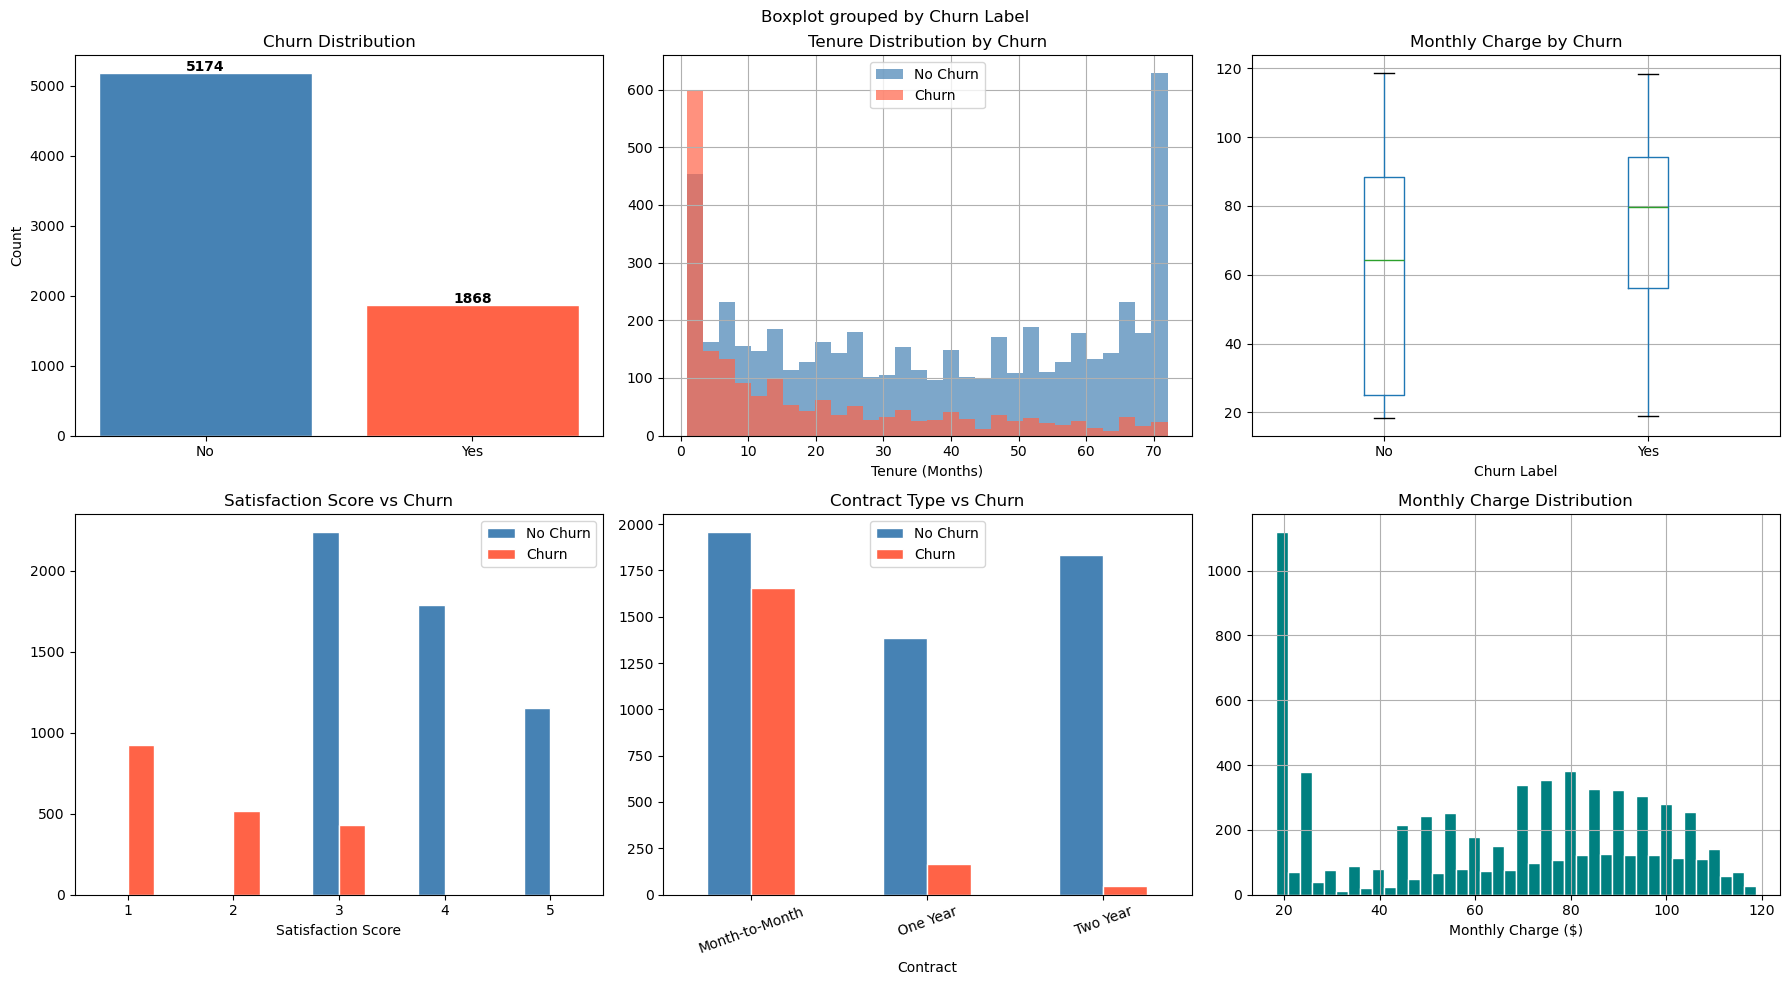

✅ EDA plots saved.


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Telecom Churn — EDA Overview', fontsize=16, fontweight='bold')

# 1. Churn distribution
churn_cnt = df['Churn Label'].value_counts()
axes[0,0].bar(churn_cnt.index, churn_cnt.values, color=['steelblue','tomato'], edgecolor='white')
axes[0,0].set_title('Churn Distribution')
axes[0,0].set_ylabel('Count')
for i, v in enumerate(churn_cnt.values):
    axes[0,0].text(i, v+30, str(v), ha='center', fontweight='bold')

# 2. Tenure by churn
for label, color, name in [('No','steelblue','No Churn'),('Yes','tomato','Churn')]:
    df[df['Churn Label']==label]['Tenure in Months'].hist(
        bins=30, alpha=0.7, label=name, color=color, ax=axes[0,1])
axes[0,1].set_title('Tenure Distribution by Churn')
axes[0,1].set_xlabel('Tenure (Months)')
axes[0,1].legend()

# 3. Monthly charge by churn
df.boxplot(column='Monthly Charge', by='Churn Label', ax=axes[0,2])
axes[0,2].set_title('Monthly Charge by Churn')
axes[0,2].set_xlabel('Churn Label')
plt.sca(axes[0,2]); plt.title('Monthly Charge by Churn')

# 4. Satisfaction score vs churn
df.groupby(['Satisfaction Score','Churn Label']).size().unstack().plot(
    kind='bar', ax=axes[1,0], color=['steelblue','tomato'], edgecolor='white')
axes[1,0].set_title('Satisfaction Score vs Churn')
axes[1,0].set_xlabel('Satisfaction Score')
axes[1,0].legend(['No Churn','Churn'])
axes[1,0].tick_params(axis='x', rotation=0)

# 5. Contract type vs churn
df.groupby(['Contract','Churn Label']).size().unstack().plot(
    kind='bar', ax=axes[1,1], color=['steelblue','tomato'], edgecolor='white')
axes[1,1].set_title('Contract Type vs Churn')
axes[1,1].legend(['No Churn','Churn'])
axes[1,1].tick_params(axis='x', rotation=20)

# 6. CLTV distribution
df['Monthly Charge'].hist(bins=40, color='teal', edgecolor='white', ax=axes[1,2])
axes[1,2].set_title('Monthly Charge Distribution')
axes[1,2].set_xlabel('Monthly Charge ($)')


plt.tight_layout()
plt.savefig('outputs/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plots saved.")

## Step 4 — Data Cleaning

In [7]:
#  Handle nulls FIRST (before any rename
df['Offer']         = df['Offer'].fillna('No Offer')
df['Internet Type'] = df['Internet Type'].fillna('No Internet')
df                  = df.dropna(subset=['Churn Label'])
print(f'Shape after null handling: {df.shape}')

# Drop leakage & irrelevant columns
leakage_cols = [
    'Customer ID', 'Churn Score', 'CLTV',
    'Customer Status',   # LEAKAGE: says 'Churned'/'Stayed' directly
    'Churn Category',    # LEAKAGE: only filled for churned customers
    'Churn Reason',      # LEAKAGE: only filled for churned customers
    'Country', 'State', 'City', 'Zip Code',
    'Latitude', 'Longitude', 'Quarter'
]
leakage_cols = [c for c in leakage_cols if c in df.columns]
df = df.drop(columns=leakage_cols)
print(f'Shape after dropping leakage cols: {df.shape}')
print(f'Remaining columns: {list(df.columns)}')

Shape after null handling: (7042, 50)
Shape after dropping leakage cols: (7042, 37)
Remaining columns: ['Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents', 'Population', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Satisfaction Score', 'Churn Label']


## Step 5 — Feature Engineering

In [8]:
# Custom CLV
df['CLV'] = df['Monthly Charge'] * df['Tenure in Months']

# Service engagement count
service_cols = ['Online Security', 'Online Backup', 'Device Protection Plan',
                'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
                'Streaming Music', 'Unlimited Data']
df['Service_Count'] = df[service_cols].apply(
    lambda row: (row == 'Yes').sum(), axis=1)

# Charges per GB
df['charges_per_gb'] = df['Monthly Charge'] / (df['Avg Monthly GB Download'] + 1)

# Long-term flag
df['is_long_term'] = (df['Tenure in Months'] > 24).astype(int)



print('New features summary:')
df[['CLV', 'Service_Count', 'charges_per_gb', 'is_long_term']].describe().round(2)

New features summary:


,CLV,Service_Count,charges_per_gb,is_long_term
count,7042.00,7042.00,7042.00,7042.00
mean,2280.15,3.07,8.57,0.54
std,2264.31,2.42,8.18,0.50
min,18.80,0.00,0.29,0.00
25%,396.21,1.00,2.38,0.00
50%,1392.60,3.00,4.44,1.00
75%,3786.65,5.00,18.02,1.00
max,8550.00,8.00,38.32,1.00


## Step 6 — Encoding & Target Preparation

In [9]:
# Encode target
df['Churn'] = df['Churn Label'].map({'Yes': 1, 'No': 0})
df = df.drop(columns=['Churn Label'])

# Binary columns
binary_cols = [
    'Under 30', 'Senior Citizen', 'Married', 'Dependents',
    'Referred a Friend', 'Phone Service', 'Multiple Lines',
    'Online Security', 'Online Backup', 'Device Protection Plan',
    'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
    'Streaming Music', 'Unlimited Data', 'Paperless Billing',
    'Internet Service'
]
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

# Gender
if 'Gender' in df.columns:
    df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# One-hot encode remaining object columns
df = pd.get_dummies(df, drop_first=True)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print(f'Final shape: {df.shape}')
print(f'Churn rate : {df["Churn"].mean():.1%}')
print(f'Columns    : {list(df.columns)}')

Final shape: (7042, 49)
Churn rate : 26.5%
Columns    : ['Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents', 'Population', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Paperless Billing', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Satisfaction Score', 'CLV', 'Service_Count', 'charges_per_gb', 'is_long_term', 'Churn', 'Offer_Offer A', 'Offer_Offer B', 'Offer_Offer C', 'Offer_Offer D', 'Offer_Offer E', 'Internet Type_DSL', 'Internet Type_Fiber Optic', 'Internet Type_No Internet', 'Contract_One Year', 'Contract_Two Year', 'Payment Method_Credit Card', 'Payment Method_M

## Step 7 — Correlation Heatmap (Post-Encoding)

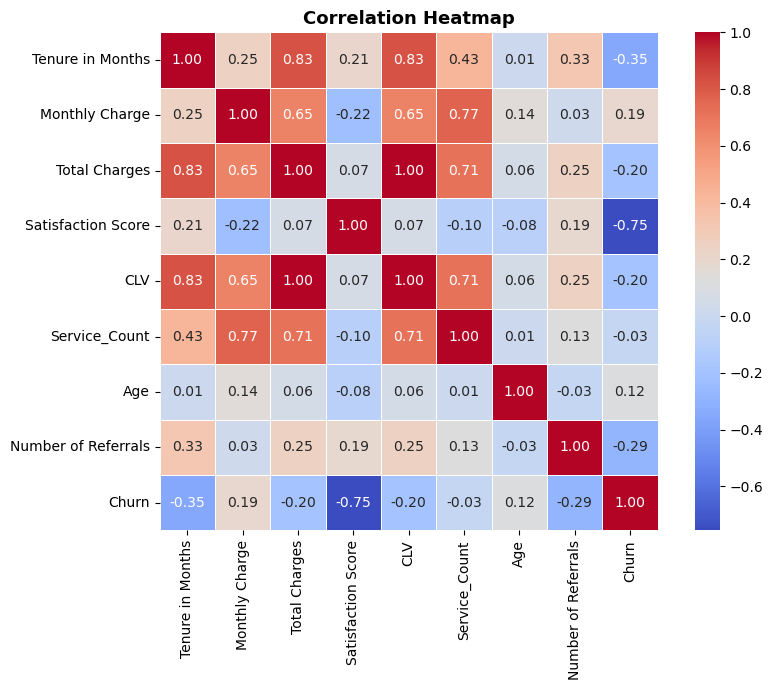

In [10]:
# Simple correlation with just numeric columns from original df
num_cols = ['Tenure in Months', 'Monthly Charge', 'Total Charges',
            'Satisfaction Score', 'CLV', 'Service_Count', 'Age',
            'Number of Referrals', 'Churn']

corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 8— Train/Test Split & SMOTE

In [11]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {X_train.shape}  |  Churn rate: {y_train.mean():.2%}')
print(f'Test : {X_test.shape}   |  Churn rate: {y_test.mean():.2%}')

# Scale
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

print(f'\nBefore SMOTE: {Counter(y_train)}')
print(f'After  SMOTE: {Counter(y_train_sm)}')

Train: (5633, 48)  |  Churn rate: 26.52%
Test : (1409, 48)   |  Churn rate: 26.54%

Before SMOTE: Counter({0: 4139, 1: 1494})
After  SMOTE: Counter({0: 4139, 1: 4139})


## Step 9— Model Training


In [12]:

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred  = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:, 1]

    results[name] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1'       : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_proba),
    }
    print(f'  {name:25s} | Acc={results[name]["Accuracy"]:.4f} | '
          f'F1={results[name]["F1"]:.4f} | AUC={results[name]["ROC-AUC"]:.4f}')

results_df = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)
print(f'\nModel Comparison:\n{results_df.round(4).to_string()}')

  Logistic Regression       | Acc=0.9610 | F1=0.9283 | AUC=0.9937
  Decision Tree             | Acc=0.9368 | F1=0.8827 | AUC=0.9237
  Random Forest             | Acc=0.9659 | F1=0.9337 | AUC=0.9856
  Gradient Boosting         | Acc=0.9652 | F1=0.9344 | AUC=0.9939

Model Comparison:
                     Accuracy  Precision  Recall      F1  ROC-AUC
Gradient Boosting      0.9652     0.9357  0.9332  0.9344   0.9939
Logistic Regression    0.9610     0.9059  0.9519  0.9283   0.9937
Random Forest          0.9659     0.9657  0.9037  0.9337   0.9856
Decision Tree          0.9368     0.8701  0.8957  0.8827   0.9237


## Step 10 — Hyperparameter Tuning 

In [13]:
# Tune only Random Forest — simple and clear
param_grid = {
    'n_estimators': [100, 200],
    'max_depth'   : [None, 10, 20],
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid.fit(X_train_sm, y_train_sm)
best_model = grid.best_estimator_

print(f'Best Parameters : {grid.best_params_}')
print(f'Best CV ROC-AUC : {grid.best_score_:.4f}')

# Evaluate on test set
y_test_pred = best_model.predict(X_test_sc)
y_test_prob = best_model.predict_proba(X_test_sc)[:, 1]
print(f'\nTest Accuracy : {accuracy_score(y_test, y_test_pred):.4f}')
print(f'Test ROC-AUC  : {roc_auc_score(y_test, y_test_prob):.4f}')
print(classification_report(y_test, y_test_pred, target_names=['No Churn', 'Churn']))

Best Parameters : {'max_depth': None, 'n_estimators': 200}
Best CV ROC-AUC : 0.9965

Test Accuracy : 0.9659
Test ROC-AUC  : 0.9857
              precision    recall  f1-score   support

    No Churn       0.97      0.99      0.98      1035
       Churn       0.96      0.91      0.93       374

    accuracy                           0.97      1409
   macro avg       0.96      0.95      0.96      1409
weighted avg       0.97      0.97      0.97      1409



## Step 11 — Model Evaluation & Visualizations

                     Accuracy  Precision  Recall      F1  ROC-AUC
Gradient Boosting      0.9652     0.9357  0.9332  0.9344   0.9939
Logistic Regression    0.9610     0.9059  0.9519  0.9283   0.9937
Random Forest          0.9659     0.9657  0.9037  0.9337   0.9856
Decision Tree          0.9368     0.8701  0.8957  0.8827   0.9237


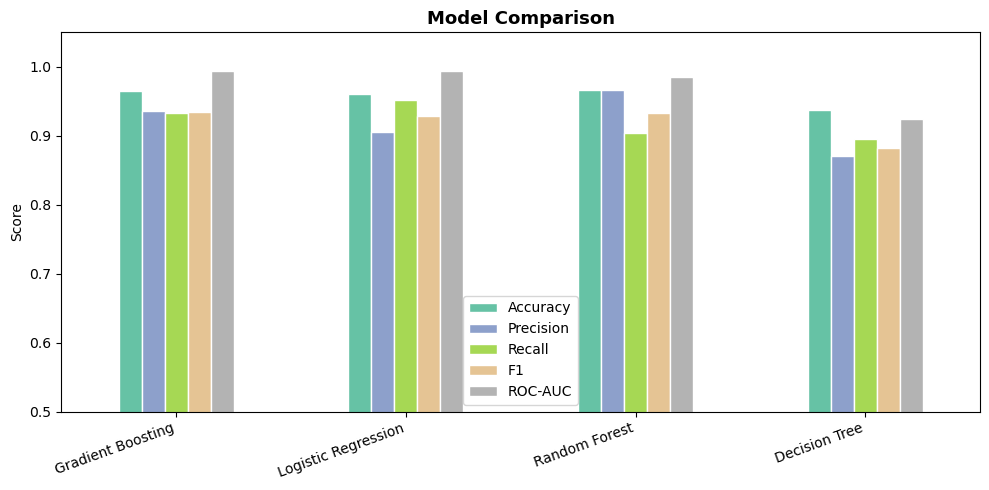

In [14]:

results_df_show = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)
print(results_df_show.round(4).to_string())

results_df_show.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='white')
plt.title('Model Comparison', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0.5, 1.05)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

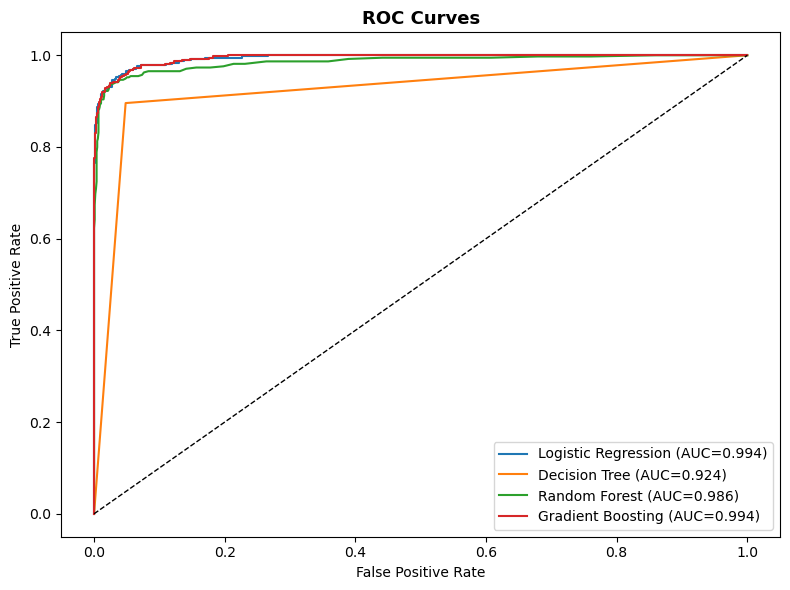

In [15]:
# ROC Curves for all models
plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Best model: Random Forest (Tuned)


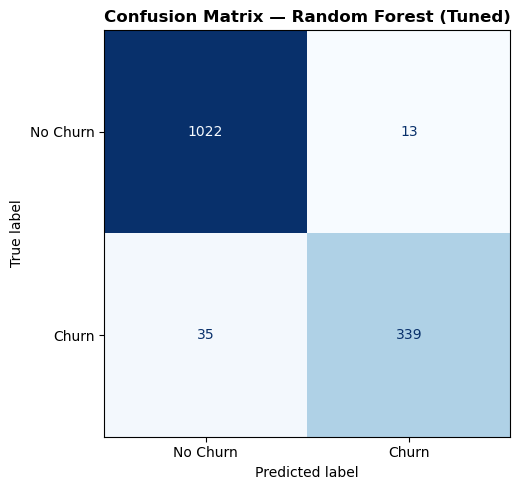


Classification Report — Random Forest (Tuned):
              precision    recall  f1-score   support

    No Churn       0.97      0.99      0.98      1035
       Churn       0.96      0.91      0.93       374

    accuracy                           0.97      1409
   macro avg       0.96      0.95      0.96      1409
weighted avg       0.97      0.97      0.97      1409



In [16]:
# Best model evaluation
best_name = 'Random Forest (Tuned)'
print(f'Best model: {best_name}')

y_pred_best  = best_model.predict(X_test_sc)
y_proba_best = best_model.predict_proba(X_test_sc)[:, 1]

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_best),
    display_labels=['No Churn', 'Churn']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nClassification Report — {best_name}:')
print(classification_report(y_test, y_pred_best, target_names=['No Churn','Churn']))

## Step 12 — Feature Importance

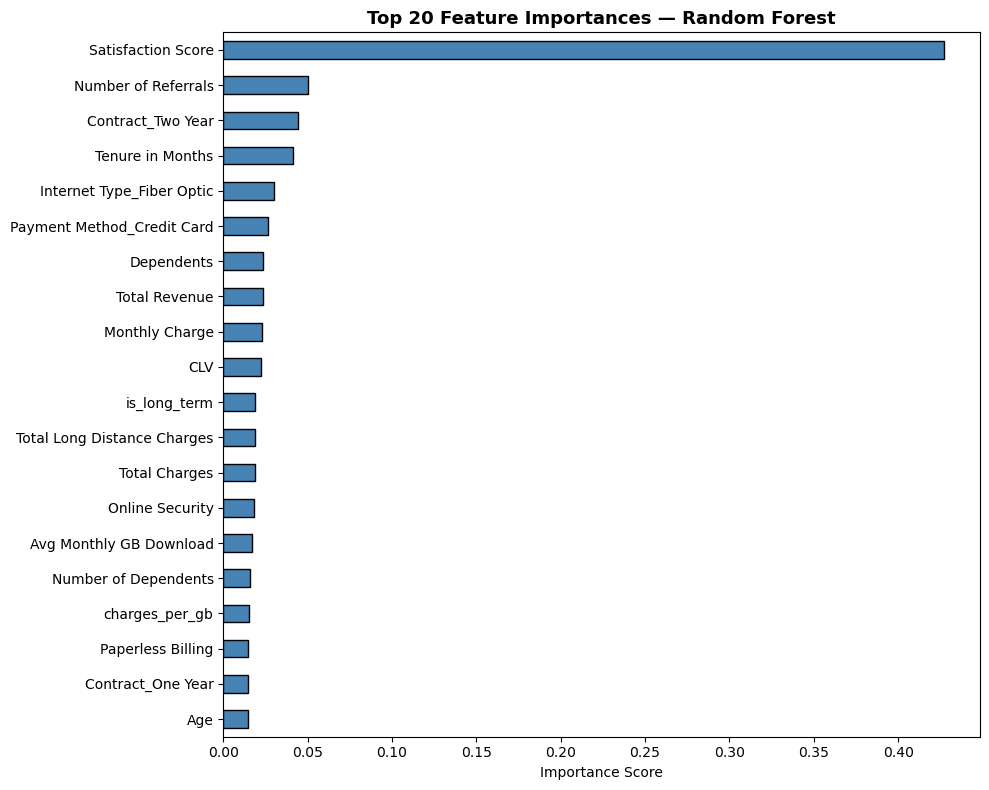

Top 10 Features:
Satisfaction Score            0.4272
Number of Referrals           0.0500
Contract_Two Year             0.0443
Tenure in Months              0.0412
Internet Type_Fiber Optic     0.0301
Payment Method_Credit Card    0.0266
Dependents                    0.0238
Total Revenue                 0.0236
Monthly Charge                0.0227
CLV                           0.0224


In [17]:
# Use the best tree-based model for feature importance
# REPLACE the entire tree_models_priority loop with:
importances = pd.Series(best_model.feature_importances_, index=X.columns)
top20 = importances.nlargest(20).sort_values()

top20.plot(kind='barh', color='steelblue', edgecolor='black', figsize=(10, 8))
plt.xlabel('Importance Score')
plt.title('Top 20 Feature Importances — Random Forest', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('Top 10 Features:')
print(importances.nlargest(10).round(4).to_string())

## Step 13 — CLV Analysis & Regression

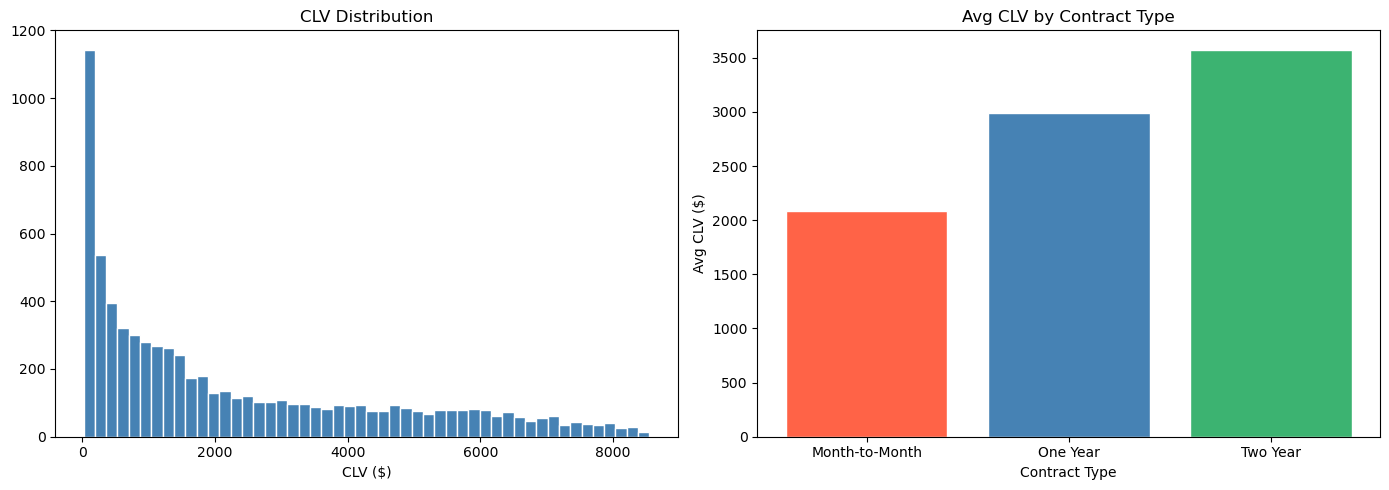

In [18]:
# 13a — CLV Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['CLV'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('CLV Distribution')
axes[0].set_xlabel('CLV ($)')
# Average CLV by contract type — reconstructed from encoded columns
clv_by_contract = {
    'Month-to-Month': df.loc[df['Contract_One Year'] == 0, 'CLV'].mean(),
    'One Year'      : df.loc[df['Contract_One Year'] == 1, 'CLV'].mean(),
    'Two Year'      : df.loc[df['Contract_Two Year'] == 1, 'CLV'].mean(),
}
axes[1].bar(clv_by_contract.keys(), clv_by_contract.values(),
            color=['tomato', 'steelblue', 'mediumseagreen'], edgecolor='white')
axes[1].set_title('Avg CLV by Contract Type')
axes[1].set_xlabel('Contract Type')
axes[1].set_ylabel('Avg CLV ($)')
plt.tight_layout()
plt.savefig('outputs/clv_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# 13b — CLV Regression
print('CLV Prediction via Regression Models')
clv_features = [c for c in df.columns if c not in ['CLV', 'Churn', 'Cluster',
                                                     'Churn Score', 'Churn Category']]
X_clv = df[clv_features]
y_clv = df['CLV']

X_clv_tr, X_clv_te, y_clv_tr, y_clv_te = train_test_split(
    X_clv, y_clv, test_size=0.2, random_state=42)

scaler_clv = StandardScaler()
X_clv_tr_sc = scaler_clv.fit_transform(X_clv_tr)
X_clv_te_sc = scaler_clv.transform(X_clv_te)

clv_models = {
    'Ridge Regression'           : Ridge(alpha=1.0),
    'Random Forest Regressor'    : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(n_estimators=100, random_state=42),
}
clv_results = {}
for name, model in clv_models.items():
    model.fit(X_clv_tr_sc, y_clv_tr)
    y_pred_clv = model.predict(X_clv_te_sc)
    clv_results[name] = {
        'RMSE': np.sqrt(mean_squared_error(y_clv_te, y_pred_clv)),
        'MAE' : mean_absolute_error(y_clv_te, y_pred_clv),
        'R²'  : r2_score(y_clv_te, y_pred_clv),
    }
    print(f'  {name:35s} | RMSE={clv_results[name]["RMSE"]:.1f} '
          f'| MAE={clv_results[name]["MAE"]:.1f} | R²={clv_results[name]["R²"]:.4f}')

clv_res_df = pd.DataFrame(clv_results).T.sort_values('R²', ascending=False)
print(f'\nCLV Regression Comparison:\n{clv_res_df.round(4).to_string()}')

CLV Prediction via Regression Models
  Ridge Regression                    | RMSE=66.9 | MAE=46.3 | R²=0.9991
  Random Forest Regressor             | RMSE=66.2 | MAE=44.1 | R²=0.9991
  Gradient Boosting Regressor         | RMSE=67.8 | MAE=47.2 | R²=0.9990

CLV Regression Comparison:
                                RMSE      MAE      R²
Random Forest Regressor      66.1579  44.1199  0.9991
Ridge Regression             66.8751  46.2697  0.9991
Gradient Boosting Regressor  67.8221  47.1570  0.9990


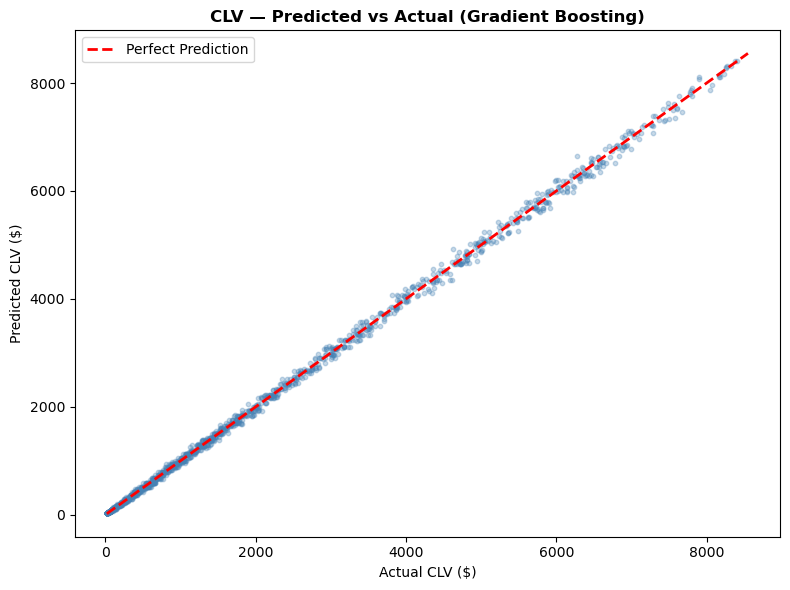

In [20]:
# Predicted vs Actual plot — best CLV model
best_clv_model = clv_models['Gradient Boosting Regressor']
y_clv_pred_best = best_clv_model.predict(X_clv_te_sc)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_clv_te, y_clv_pred_best, alpha=0.3, color='steelblue', s=10)
lim = [y_clv.min(), y_clv.max()]
ax.plot(lim, lim, 'r--', lw=2, label='Perfect Prediction')
ax.set_title('CLV — Predicted vs Actual (Gradient Boosting)', fontsize=12, fontweight='bold')
ax.set_xlabel('Actual CLV ($)')
ax.set_ylabel('Predicted CLV ($)')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/clv_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

Churn Rate by CLV Segment (%):
CLV_Segment
Low CLV       39.3
Medium CLV    24.0
High CLV      16.4


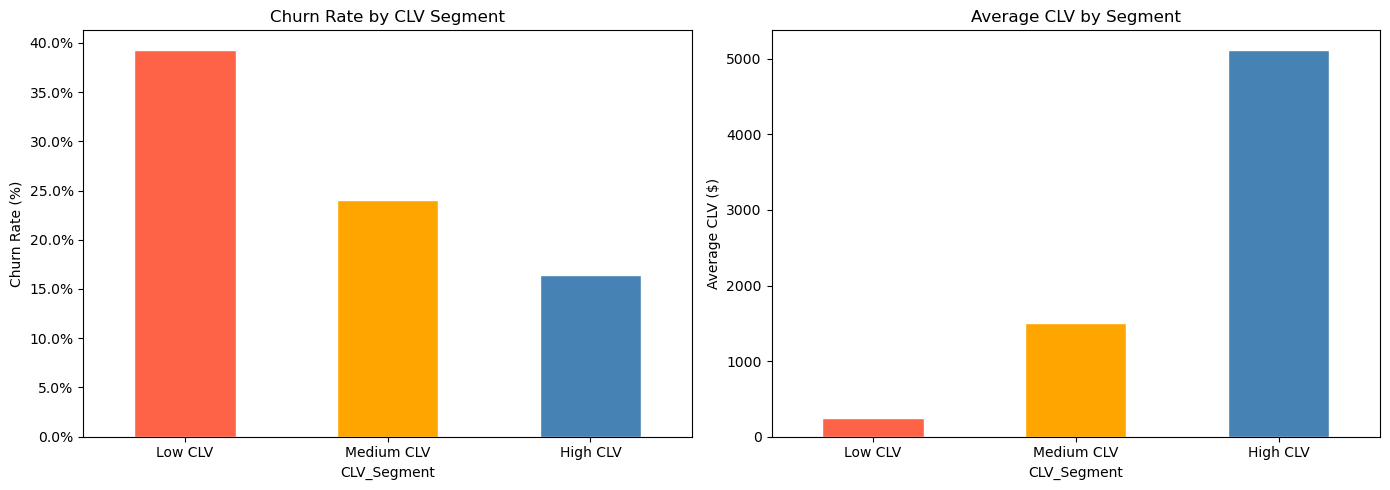

In [21]:
# 13c — CLV Segmentation (Low / Medium / High)
clv_q = df['CLV'].quantile([0.33, 0.67])
df['CLV_Segment'] = pd.cut(
    df['CLV'],
    bins=[-np.inf, clv_q.iloc[0], clv_q.iloc[1], np.inf],
    labels=['Low CLV', 'Medium CLV', 'High CLV']
)

clv_seg_churn = df.groupby('CLV_Segment', observed=True)['Churn'].mean().mul(100).round(1)
print('Churn Rate by CLV Segment (%):')
print(clv_seg_churn.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
clv_seg_churn.plot(kind='bar', ax=axes[0],
                   color=['tomato','orange','steelblue'], edgecolor='white')
axes[0].set_title('Churn Rate by CLV Segment')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].tick_params(axis='x', rotation=0)

df.groupby('CLV_Segment', observed=True)['CLV'].mean().plot(
    kind='bar', ax=axes[1], color=['tomato','orange','steelblue'], edgecolor='white')
axes[1].set_title('Average CLV by Segment')
axes[1].set_ylabel('Average CLV ($)')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('outputs/clv_segments.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 14 — 4-Quadrant Customer Segmentation

In [22]:
# Churn probabilities on full dataset
X = X.drop(columns=['Cluster'], errors='ignore')
df['Churn_Prob'] = best_model.predict_proba(scaler.transform(X))[:, 1]

clv_median  = df['CLV'].median()
risk_thresh = 0.5

def assign_segment(row):
    h_clv  = row['CLV']        > clv_median
    h_risk = row['Churn_Prob'] > risk_thresh
    if   h_clv  and h_risk:     return 'High Value - High Risk'
    elif h_clv  and not h_risk: return 'High Value - Low Risk'
    elif not h_clv and h_risk:  return 'Low Value  - High Risk'
    else:                       return 'Low Value  - Low Risk'

df['Segment'] = df.apply(assign_segment, axis=1)

seg_counts = df['Segment'].value_counts()
print('Segment Distribution:')
print(seg_counts)

seg_summary = df.groupby('Segment').agg(
    Count        =('CLV', 'count'),
    Avg_CLV      =('CLV', 'mean'),
    Total_CLV    =('CLV', 'sum'),
    Avg_ChurnProb=('Churn_Prob', 'mean'),
    Churn_Rate   =('Churn', 'mean')
).round(2).sort_values('Avg_CLV', ascending=False)
print('\nSegment Summary:')
print(seg_summary.to_string())

Segment Distribution:
Segment
High Value - Low Risk     2873
Low Value  - Low Risk     2323
Low Value  - High Risk    1198
High Value - High Risk     648
Name: count, dtype: int64

Segment Summary:
                        Count  Avg_CLV    Total_CLV  Avg_ChurnProb  Churn_Rate
Segment                                                                       
High Value - Low Risk    2873  4153.79  11933825.30           0.03        0.00
High Value - High Risk    648  3612.15   2340672.60           0.91        1.00
Low Value  - Low Risk    2323   566.64   1316294.05           0.05        0.01
Low Value  - High Risk   1198   389.00    466025.00           0.94        0.99


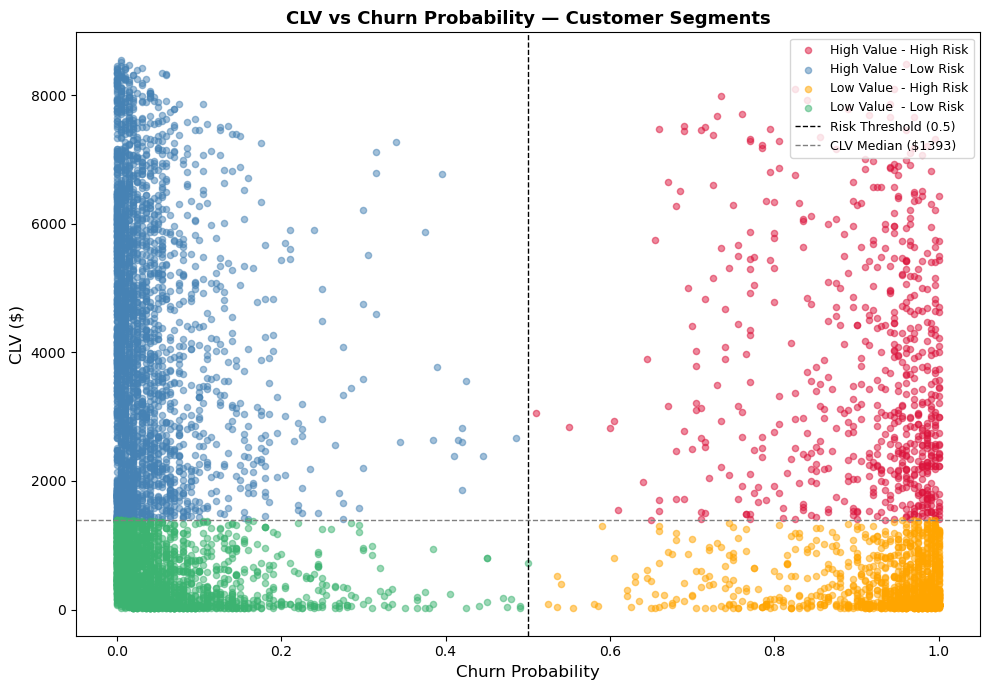

In [23]:
# Scatter plot: CLV vs Churn Probability
seg_colors = {
    'High Value - High Risk': 'crimson',
    'High Value - Low Risk' : 'steelblue',
    'Low Value  - High Risk': 'orange',
    'Low Value  - Low Risk' : 'mediumseagreen'
}

plt.figure(figsize=(10, 7))
for seg, color in seg_colors.items():
    mask = df['Segment'] == seg
    plt.scatter(df.loc[mask, 'Churn_Prob'], df.loc[mask, 'CLV'],
                c=color, label=seg, alpha=0.5, s=20)
plt.axvline(x=risk_thresh, color='black', linestyle='--', linewidth=1,
            label=f'Risk Threshold ({risk_thresh})')
plt.axhline(y=clv_median, color='grey', linestyle='--', linewidth=1,
            label=f'CLV Median (${clv_median:.0f})')
plt.xlabel('Churn Probability', fontsize=12)
plt.ylabel('CLV ($)', fontsize=12)
plt.title('CLV vs Churn Probability — Customer Segments', fontweight='bold', fontsize=13)
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('outputs/segment_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 15 — Save Outputs & Models

In [24]:
# Save customer output
output = df[['Churn_Prob', 'CLV', 'CLV_Segment', 'Segment']].copy()
output.index.name = 'customer_index'
output.to_csv('outputs/churn_clv_output.csv')
print('Saved: outputs/churn_clv_output.csv')

seg_summary.to_csv('outputs/segment_summary.csv')
print('Saved: outputs/segment_summary.csv')

joblib.dump(best_model, 'models/churn_model.pkl')
joblib.dump(scaler,     'models/scaler.pkl')
print('Saved: models/churn_model.pkl, models/scaler.pkl')

print('\n✅ All outputs saved.')

Saved: outputs/churn_clv_output.csv
Saved: outputs/segment_summary.csv
Saved: models/churn_model.pkl, models/scaler.pkl

✅ All outputs saved.


## Step 16 — Final Business Summary

In [25]:
# Print final summary
# Get metrics directly from the best model results
best_churn_auc = roc_auc_score(y_test, y_test_prob)
best_churn_f1  = f1_score(y_test, y_test_pred)
best_clv_r2    = clv_res_df['R²'].iloc[0]
best_clv_rmse  = clv_res_df['RMSE'].iloc[0]

high_risk_segment = df[df['Segment'] == 'High Value - High Risk']
clv_at_risk = high_risk_segment['CLV'].sum()

print('=' * 60)
print('         FINAL PROJECT SUMMARY')
print('=' * 60)
print(f'  Dataset         : {df.shape[0]:,} customers')
print(f'  Churn Rate      : {df["Churn"].mean():.1%}')
print(f'  Best Classifier : Random Forest (Tuned)')
print(f'  Best AUC        : {best_churn_auc:.4f}')
print(f'  Best F1         : {best_churn_f1:.4f}')
print(f'  CLV Model R²    : {best_clv_r2:.4f}')
print(f'  CLV Model RMSE  : ${best_clv_rmse:.0f}')
print(f'  High-Risk Count : {len(high_risk_segment):,} customers')
print(f'  CLV at Risk     : ${clv_at_risk:,.0f}')
print('=' * 60)

         FINAL PROJECT SUMMARY
  Dataset         : 7,042 customers
  Churn Rate      : 26.5%
  Best Classifier : Random Forest (Tuned)
  Best AUC        : 0.9857
  Best F1         : 0.9339
  CLV Model R²    : 0.9991
  CLV Model RMSE  : $66
  High-Risk Count : 648 customers
  CLV at Risk     : $2,340,673
